In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 확인
print("폰트 설정 완료!")

폰트 설정 완료!


In [7]:
from pathlib import Path
import pandas as pd

# 현재 작업 폴더 기준 (노트북이 있는 폴더)
DATA_PATH = Path("online_retail_II.xlsx")

df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

print(df_2009.shape)
print(df_2009.head())

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [12]:
# 합친 후 바로 분리
df = pd.concat([df_2009, df_2010], ignore_index=True)

# 날짜 타입 변환
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Train/Test 분리
train = df[df['InvoiceDate'] < '2011-10-01']
test  = df[df['InvoiceDate'] >= '2011-10-01']

print(f"Train: {len(train):,}행")
print(f"Train 기간: {train['InvoiceDate'].min()} ~ {train['InvoiceDate'].max()}")
print(f"\nTest: {len(test):,}행")
print(f"Test 기간: {test['InvoiceDate'].min()} ~ {test['InvoiceDate'].max()}")

Train: 896,392행
Train 기간: 2009-12-01 07:45:00 ~ 2011-09-30 17:22:00

Test: 170,979행
Test 기간: 2011-10-02 10:32:00 ~ 2011-12-09 12:50:00


In [20]:
# 1. 합치기
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"2009-2010 시트: {len(df_2009):,}행")
print(f"2010-2011 시트: {len(df_2010):,}행")
print(f"합친 후 전체: {len(df):,}행")

# 2. 날짜 범위 확인
print(f"\n날짜 범위:")
print(f"시작: {df['InvoiceDate'].min()}")
print(f"종료: {df['InvoiceDate'].max()}")

# 3. 결측치 확인
print(f"\n결측치:")
print(df.isnull().sum())

# 4. 중복행 확인
print(f"\n중복행: {df.duplicated().sum():,}개")

# 칼럼별 결측치 + 사분위수 함께 보기
desc = df.describe()
desc.loc['missing'] = df.isnull().sum()
print(desc)

2009-2010 시트: 525,461행
2010-2011 시트: 541,910행
합친 후 전체: 1,067,371행

날짜 범위:
시작: 2009-12-01 07:45:00
종료: 2011-12-09 12:50:00

결측치:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

중복행: 34,335개
             Quantity                    InvoiceDate         Price  \
count    1.067371e+06                        1067371  1.067371e+06   
mean     9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min     -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   
25%      1.000000e+00            2010-07-09 09:46:00  1.250000e+00   
50%      3.000000e+00            2010-12-07 15:28:00  2.100000e+00   
75%      1.000000e+01            2011-07-22 10:23:00  4.150000e+00   
max      8.099500e+04            2011-12-09 12:50:00  3.897000e+04   
std      1.727058e+02                            NaN  1.235531e+02   
missing  0.000000e+00                  

In [ ]:
# Train 데이터만 전처리
df_train = train.copy()

# 1. 취소 주문 제거 (Invoice가 C로 시작)
df_train = df_train[~df_train['Invoice'].astype(str).str.startswith('C')]
print(f"취소 주문 제거 후: {len(df_train):,}행")

# 2. Customer ID 결측치 제거
df_train = df_train.dropna(subset=['Customer ID'])
print(f"Customer ID 결측치 제거 후: {len(df_train):,}행")

# 3. Quantity, Price 이상치 제거
# 0 이하 제거
df_train = df_train[df_train['Quantity'] > 0]ㅇ
df_train = df_train[df_train['Price'] > 0]
print(f"이상치 제거 후: {len(df_train):,}행")

# 4. Sales 컬럼 생성
df_train['Sales'] = df_train['Quantity'] * df_train['Price']
print(f"\n전처리 완료!")
print(f"최종 Train: {len(df_train):,}행")
print(df_train[['Invoice','Quantity','Price','Sales']].head())

취소 주문 제거 후: 879,534행
Customer ID 결측치 제거 후: 674,213행
이상치 제거 후: 674,159행

전처리 완료!
최종 Train: 674,159행
  Invoice  Quantity  Price  Sales
0  489434        12   6.95   83.4
1  489434        12   6.75   81.0
2  489434        12   6.75   81.0
3  489434        48   2.10  100.8
4  489434        24   1.25   30.0


=== 코호트별 기간별 재구매율 (2009-12 ~ 2010-09) ===
           고객수  재구매_1M  재구매_3M  재구매_6M  재구매_12M
CohortStr                                      
2009-12    955    90.2    88.6    85.4     71.4
2010-01    383    86.2    83.8    78.6     61.6
2010-02    374    83.4    80.5    74.1     54.0
2010-03    443    79.7    77.9    72.0     54.4
2010-04    294    74.8    72.4    65.3     46.3
2010-05    254    72.8    68.5    54.3     37.4
2010-06    270    69.3    65.2    49.3     31.9
2010-07    186    68.8    64.0    47.8     33.9
2010-08    162    65.4    61.1    50.0     27.2
2010-09    243    63.4    49.4    42.0     21.8


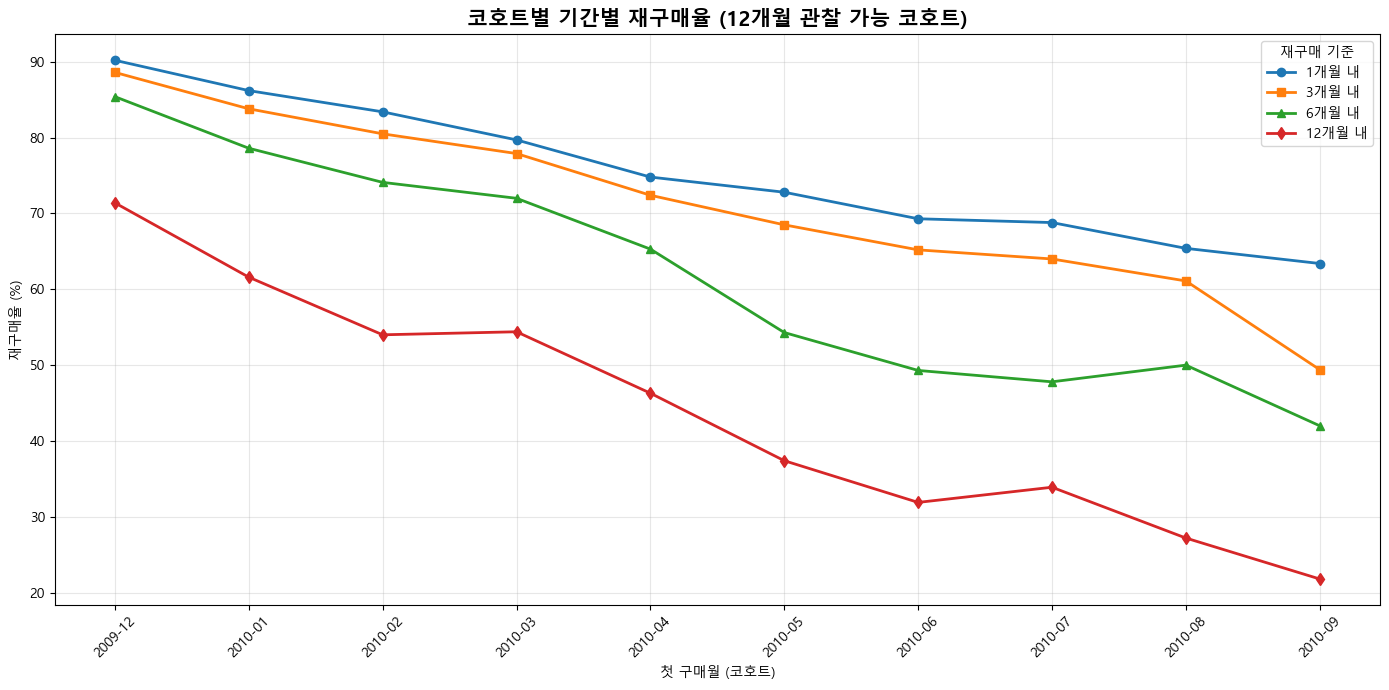


=== 인사이트 ===
12개월 재구매율 최고: 2009-12 (71.4%)
12개월 재구매율 최저: 2010-09 (21.8%)
평균 12개월 재구매율: 44.0%


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 고객별 최대 경과 개월
customer_repurchase = df_train.groupby('Customer ID').agg(
    CohortMonth = ('CohortMonth', 'first'),
    MaxPeriod   = ('PeriodNumber', 'max')
).reset_index()

customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)

# 재구매 기준별 여부
customer_repurchase['Repurchased_1M']  = (customer_repurchase['MaxPeriod'] >= 1).astype(int)
customer_repurchase['Repurchased_3M']  = (customer_repurchase['MaxPeriod'] >= 3).astype(int)
customer_repurchase['Repurchased_6M']  = (customer_repurchase['MaxPeriod'] >= 6).astype(int)
customer_repurchase['Repurchased_12M'] = (customer_repurchase['MaxPeriod'] >= 12).astype(int)

# 코호트별 재구매율
cohort_repurchase = customer_repurchase.groupby('CohortStr').agg(
    고객수      = ('Customer ID', 'count'),
    재구매_1M   = ('Repurchased_1M', lambda x: x.mean()*100),
    재구매_3M   = ('Repurchased_3M', lambda x: x.mean()*100),
    재구매_6M   = ('Repurchased_6M', lambda x: x.mean()*100),
    재구매_12M  = ('Repurchased_12M', lambda x: x.mean()*100)
).round(1)

# 2010-09까지만 필터 (12개월 관찰 가능한 코호트만)
cohort_repurchase = cohort_repurchase[cohort_repurchase.index <= '2010-09']

print("=== 코호트별 기간별 재구매율 (2009-12 ~ 2010-09) ===")
print(cohort_repurchase.to_string())

# 시각화
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(cohort_repurchase))
ax.plot(x, cohort_repurchase['재구매_1M'], marker='o', label='1개월 내', linewidth=2)
ax.plot(x, cohort_repurchase['재구매_3M'], marker='s', label='3개월 내', linewidth=2)
ax.plot(x, cohort_repurchase['재구매_6M'], marker='^', label='6개월 내', linewidth=2)
ax.plot(x, cohort_repurchase['재구매_12M'], marker='d', label='12개월 내', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(cohort_repurchase.index, rotation=45)
ax.set_title('코호트별 기간별 재구매율 (12개월 관찰 가능 코호트)', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('첫 구매월 (코호트)')
ax.set_ylabel('재구매율 (%)')
ax.legend(title='재구매 기준')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cohort_repurchase_2010_09.png', dpi=150)
plt.show()

# 인사이트
print(f"\n=== 인사이트 ===")
print(f"12개월 재구매율 최고: {cohort_repurchase['재구매_12M'].idxmax()} ({cohort_repurchase['재구매_12M'].max()}%)")
print(f"12개월 재구매율 최저: {cohort_repurchase['재구매_12M'].idxmin()} ({cohort_repurchase['재구매_12M'].min()}%)")
print(f"평균 12개월 재구매율: {cohort_repurchase['재구매_12M'].mean():.1f}%")

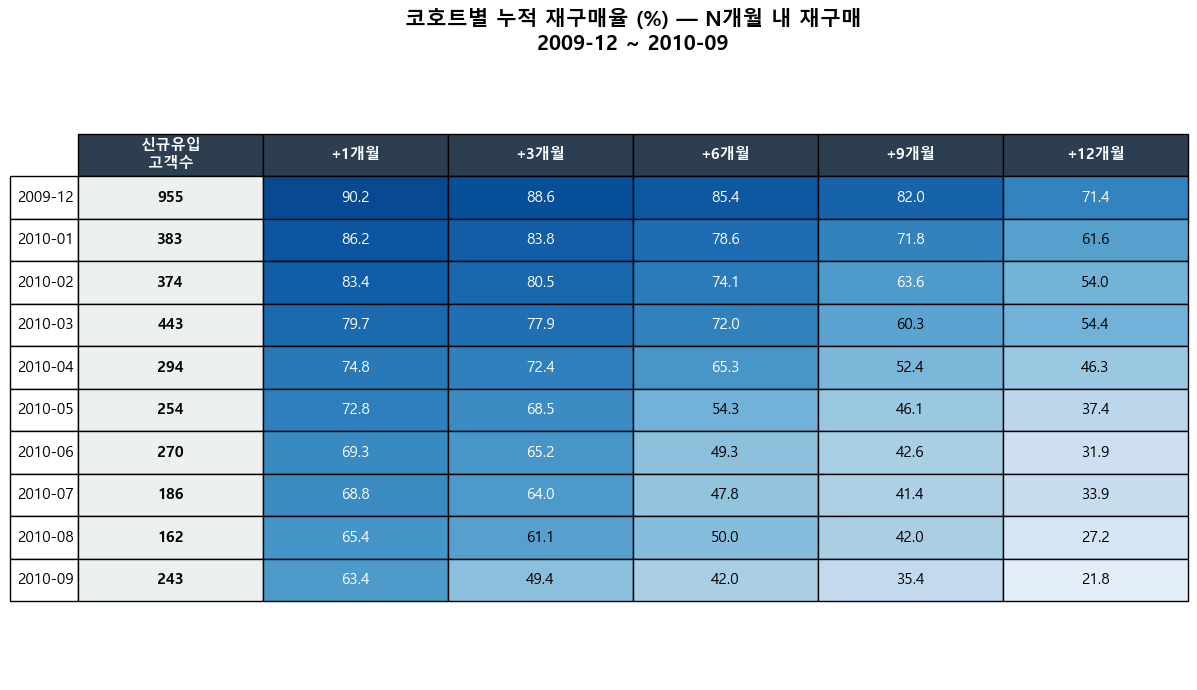

=== 누적 재구매율 표 ===
         +1개월  +3개월  +6개월  +9개월  +12개월
Cohort                                
2009-12  90.2  88.6  85.4  82.0   71.4
2010-01  86.2  83.8  78.6  71.8   61.6
2010-02  83.4  80.5  74.1  63.6   54.0
2010-03  79.7  77.9  72.0  60.3   54.4
2010-04  74.8  72.4  65.3  52.4   46.3
2010-05  72.8  68.5  54.3  46.1   37.4
2010-06  69.3  65.2  49.3  42.6   31.9
2010-07  68.8  64.0  47.8  41.4   33.9
2010-08  65.4  61.1  50.0  42.0   27.2
2010-09  63.4  49.4  42.0  35.4   21.8


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 고객별 최대 경과 개월 (이미 있으면 재사용)
customer_repurchase = df_train.groupby('Customer ID').agg(
    CohortMonth = ('CohortMonth', 'first'),
    MaxPeriod   = ('PeriodNumber', 'max')
).reset_index()
customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)

# 누적 재구매율 계산 (N개월 내 재구매)
periods = [1, 3, 6, 9, 12]
cohort_list = sorted(customer_repurchase['CohortStr'].unique())

cumulative_data = []
for cohort in cohort_list:
    cohort_customers = customer_repurchase[
        customer_repurchase['CohortStr'] == cohort
    ]
    row = {'Cohort': cohort, '신규유입': len(cohort_customers)}
    for p in periods:
        # N개월 내 재구매 = MaxPeriod >= p
        rate = (cohort_customers['MaxPeriod'] >= p).mean() * 100
        row[f'+{p}개월'] = rate
    cumulative_data.append(row)

cumulative_df = pd.DataFrame(cumulative_data).set_index('Cohort')

# 2010-09까지만 (12개월 관찰 가능)
cumulative_df = cumulative_df[cumulative_df.index <= '2010-09']

# 표 그리기
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

col_labels = ['신규유입\n고객수'] + [f'+{p}개월' for p in periods]
row_labels = cumulative_df.index.tolist()

# 셀 텍스트
cell_text = []
for cohort in cumulative_df.index:
    row = [f"{int(cumulative_df.loc[cohort, '신규유입'])}"]
    for p in periods:
        val = cumulative_df.loc[cohort, f'+{p}개월']
        row.append(f'{val:.1f}')
    cell_text.append(row)

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.2)

# 색상: 재구매율 높을수록 진한 파랑
value_cols = [f'+{p}개월' for p in periods]
all_vals = cumulative_df[value_cols].values.flatten()
vmin, vmax = all_vals.min(), all_vals.max()

blues = plt.cm.Blues

for i, cohort in enumerate(cumulative_df.index):
    for j, p in enumerate(periods):
        val = cumulative_df.loc[cohort, f'+{p}개월']
        cell = table[i+1, j+1]
        norm = (val - vmin) / (vmax - vmin)
        color = blues(0.1 + norm * 0.8)
        cell.set_facecolor(color)
        if norm > 0.6:
            cell.set_text_props(color='white')

# 헤더
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 신규유입 컬럼
for i in range(len(row_labels)):
    table[i+1, 0].set_facecolor('#ecf0f1')
    table[i+1, 0].set_text_props(fontweight='bold')

plt.title('코호트별 누적 재구매율 (%) — N개월 내 재구매\n2009-12 ~ 2010-09', 
          fontsize=15, fontweight='bold', pad=1)
plt.tight_layout()
plt.savefig('cohort_cumulative_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== 누적 재구매율 표 ===")
print(cumulative_df[value_cols].round(1).to_string())